# Bias Variance Trade-Offs in RL
Julian Hsu
2025-May-01


## Problem Setup
We are running an experiment where we must decide the proportion p of users to assign to the treatment group. However, the reward is negatively impacted by treatment (bias). But this may be imprecise. Therefore there is negative rewards from allocating more users to treatment. However, allocating more can increase precision (variance).

In reinforcement learning, the agent must learn the treatment effect while also maximizing reward—a tension between learning and earning.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(42)


In [2]:
def calculate_statistics(treatment_outcomes, control_outcomes, p):
    """Reward and pooled-outcome variance at allocation p.

    Everything here is computed from OBSERVED outcomes only -- the agent
    never uses true_effect. T_bar - C_bar is just the noisy observed gap.
    """
    T_bar = np.mean(treatment_outcomes)
    C_bar = np.mean(control_outcomes)
    var_T = np.var(np.array(treatment_outcomes), ddof=1)
    var_C = np.var(np.array(control_outcomes), ddof=1)
    if np.isnan(var_T):
        var_T = 100.0
    if np.isnan(var_C):
        var_C = 100.0

    # Observed average reward delivered to users under this allocation.
    reward = p * T_bar + (1 - p) * C_bar

    # Pooled variance of delivered outcomes (law of total variance):
    #   within-arm:  p*var_T + (1-p)*var_C
    #   between-arm: p*(1-p)*(T_bar - C_bar)**2   <-- MAXIMIZED at p = 0.5
    # So this statistic RISES as the allocation approaches a 50/50 balance,
    # and falls toward the corners (p -> 0 or p -> 1).
    variance = (p * var_T + (1 - p) * var_C
                + p * (1 - p) * (T_bar - C_bar) ** 2)
    return reward, variance


def loss(reward, variance, lambda_weight):
    # Minimized by the agent: it wants HIGH reward and LOW pooled variance.
    # lambda_weight >= 0 is the variance-aversion weight.
    return -reward + lambda_weight * variance


def choose_best_allocation(treatment_outcomes, control_outcomes, best_loss, p_grid, lambda_weight):
    # Until each arm has a little data, explore with a balanced split.
    if len(treatment_outcomes) < 2 or len(control_outcomes) < 2:
        return 0.5, best_loss

    best_p = p_grid[len(p_grid) // 2]   # default: balanced
    for p in p_grid:
        reward, variance = calculate_statistics(treatment_outcomes, control_outcomes, p)
        cur = loss(reward, variance, lambda_weight)
        if cur < best_loss:
            best_loss = cur
            best_p = p
    return best_p, best_loss


In [3]:
def outputs(lambda_weight=None):
    # Storage
    allocation_history = []
    mean_estimate_history = []
    accumulative_mean_estimate_history = []
    loss_history = []

    # Observed data accumulated so far
    treatment_outcomes = []
    control_outcomes = []

    for t in range(T):
        # Pick the allocation that minimizes  -reward + lambda * pooled_variance,
        # using only the data observed so far.
        best_loss = float('inf')
        best_p, best_loss = choose_best_allocation(
            treatment_outcomes, control_outcomes, best_loss, p_grid, lambda_weight)
        loss_history.append(best_loss)

        # Realize the chosen allocation (keep at least one user in each arm).
        n_treat = int(round(n_per_round * best_p))
        n_treat = min(max(n_treat, 1), n_per_round - 1)
        n_control = n_per_round - n_treat
        allocation_history.append([n_treat, n_control])

        # Draw outcomes: treatment arm carries the (unknown) effect and its own noise.
        treat_outcomes = true_effect + np.random.normal(0, noise_treat, n_treat)
        cont_outcomes = np.random.normal(0, noise_control, n_control)

        treatment_outcomes.extend(treat_outcomes)
        control_outcomes.extend(cont_outcomes)

        mean_estimate_history.append(np.mean(treat_outcomes) - np.mean(cont_outcomes))
        accumulative_mean_estimate_history.append(
            np.mean(treatment_outcomes) - np.mean(control_outcomes))

    return {
        "allocations": allocation_history,
        "estimates": mean_estimate_history,
        "accumulative_estimates": accumulative_mean_estimate_history,
        "losses": loss_history,
    }


In [4]:
import pandas as pd

In [5]:
###### Parameters
# The agent NEVER sees these values -- it only observes realized outcomes.
true_effect   = -3     # treatment lowers the outcome (the "bias": treatment looks worse in the data)
noise_control = 12     # control arm is the noisier arm
noise_treat   = 6      # treatment arm is the lower-variance arm
                       #   -> the low-pooled-variance corner is "all treatment" (less control)

n_per_round   = 50     # users assigned each round (fine allocation granularity)
T             = 20     # number of rounds
p_grid        = np.linspace(0.05, 0.95, 19)   # candidate treatment proportions


In [6]:
lambda_values = [0.0, 0.01, 0.03, 0.1]   # variance-aversion weight (0 = pure reward)
n_runs = 50

# Store results for each lambda
results_by_lambda = {
    lw: [outputs(lambda_weight=lw) for _ in range(n_runs)]
    for lw in lambda_values
}

def extract_df(results, key):
    return pd.DataFrame([
        [a[0] / (a[0] + a[1]) if key == "allocations" else a
         for a in run[key]]
        for run in results
    ])

alloc_dfs = {lw: extract_df(results_by_lambda[lw], "allocations") for lw in lambda_values}
impact_dfs = {lw: extract_df(results_by_lambda[lw], "accumulative_estimates") for lw in lambda_values}
loss_dfs = {lw: extract_df(results_by_lambda[lw], "losses") for lw in lambda_values}


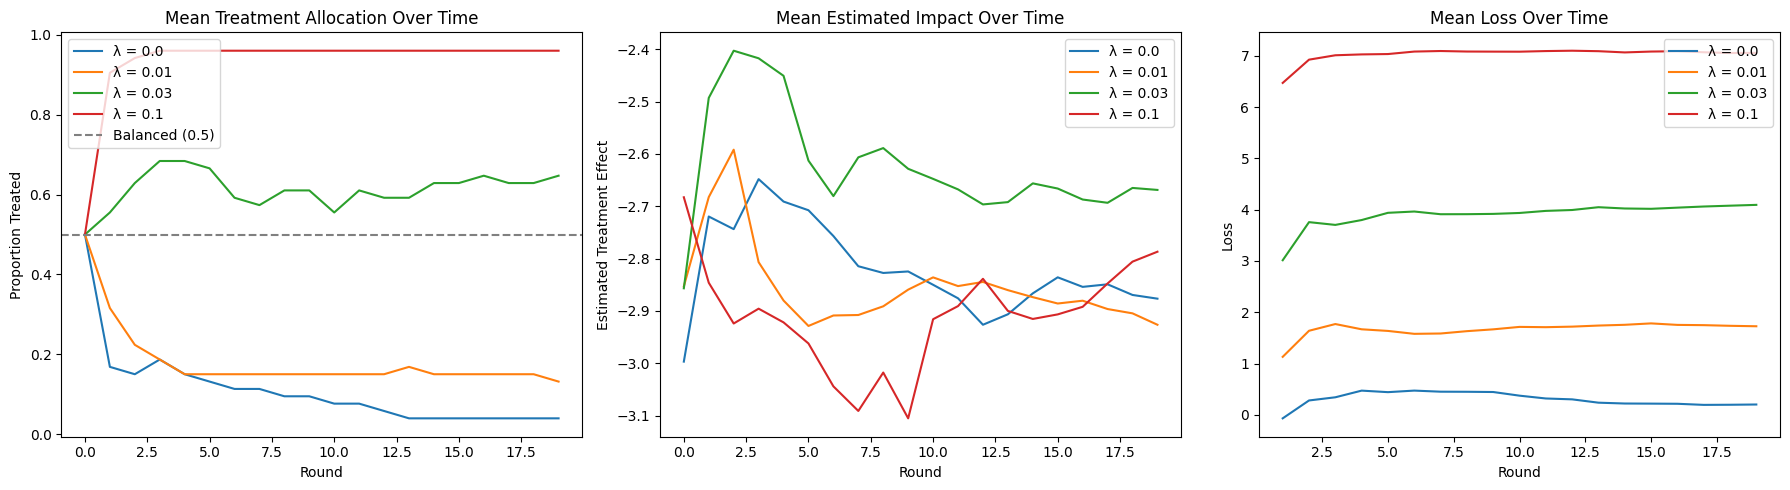

In [7]:
plt.figure(figsize=(18, 5))

# Allocation plot
plt.subplot(1, 3, 1)
for lw in lambda_values:
    plt.plot(alloc_dfs[lw].mean(axis=0), label=f'λ = {lw}')
plt.axhline(0.5, linestyle='--', color='gray', label='Balanced (0.5)')
plt.title('Mean Treatment Allocation Over Time')
plt.xlabel('Round')
plt.ylabel('Proportion Treated')
plt.legend()

# Impact plot
plt.subplot(1, 3, 2)
for lw in lambda_values:
    plt.plot(impact_dfs[lw].mean(axis=0), label=f'λ = {lw}')
plt.title('Mean Estimated Impact Over Time')
plt.xlabel('Round')
plt.ylabel('Estimated Treatment Effect')
plt.legend()

# Loss plot
plt.subplot(1, 3, 3)
for lw in lambda_values:
    plt.plot(loss_dfs[lw].mean(axis=0), label=f'λ = {lw}')
plt.title('Mean Loss Over Time')
plt.xlabel('Round')
plt.ylabel('Loss')
plt.legend()

plt.tight_layout()
plt.show()
